In [ ]:
print("NeuroManifold Research Project")
print("Author: Sugasini Balakrishnan")
print("Project: Robust Neural Decoding via Manifold Geometry")

NeuroManifold Research Project
Author: Sugasini Balakrishnan
Project: Robust Neural Decoding via Manifold Geometry


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip -q install dandi pynwb h5py numpy pandas matplotlib scikit-learn scipy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import pynwb
import dandi

print("✅ NeuroManifold environment ready!")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("PyNWB:", pynwb.__version__)

✅ NeuroManifold environment ready!
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
PyNWB: 4.1.0


In [ ]:
from dandi.dandiapi import DandiAPIClient

client = DandiAPIClient()
dandiset = client.get_dandiset("000128", "draft")

metadata = dandiset.get_metadata()

print("✅ Connected to DANDI")
print("Dataset:", metadata.name)
print("Dandiset ID:", dandiset.identifier)

✅ Connected to DANDI
Dataset: MC_Maze: macaque primary motor and dorsal premotor cortex spiking activity during delayed reaching
Dandiset ID: 000128


In [ ]:
files = list(dandiset.get_assets())

print("Number of files:", len(files))
print("\nFiles:")

for i, asset in enumerate(files):
    print(i, asset.path)

Number of files: 2

Files:
0 sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb
1 sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb


In [ ]:
print("📁 DATASET FILE INSPECTION")
print("=" * 60)

for i, asset in enumerate(files):
    print(f"\nFile {i}:")
    print("Path:", asset.path)
    print("Size:", getattr(asset, "size", "Not available"))
    print("Asset ID:", getattr(asset, "identifier", "Not available"))

📁 DATASET FILE INSPECTION

File 0:
Path: sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb
Size: 3392688
Asset ID: 1bd112a4-5ec5-4033-ac30-d88e70e993d9

File 1:
Path: sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb
Size: 690612247
Asset ID: 26e85f09-39b7-480f-b337-278a8f034007


In [ ]:
test_asset = files[0]

print("📄 Selected file:")
print(test_asset.path)
print()
print("🔗 Getting download URL...")

url = test_asset.get_content_url(
    follow_redirects=True,
    strip_query=True
)

print("✅ URL obtained")
print(url)

📄 Selected file:
sub-Jenkins/sub-Jenkins_ses-full_desc-test_ecephys.nwb

🔗 Getting download URL...


ERROR:dandi:Error 403 while sending HEAD request to https://api.dandiarchive.org/api/assets/1bd112a4-5ec5-4033-ac30-d88e70e993d9/download/: 


✅ URL obtained
https://dandiarchive.s3.amazonaws.com/blobs/faf/1f3/faf1f307-a06d-464c-8700-a659ab94ce2a


In [ ]:
from pathlib import Path

output_file = "/content/mc_maze_test.nwb"

print("⬇️ Downloading the 3.39 MB test neural recording...")
test_asset.download(output_file)

print("✅ Download complete!")
print("File:", output_file)
print("Size (MB):", round(Path(output_file).stat().st_size / 1024**2, 2))

⬇️ Downloading the 3.39 MB test neural recording...


INFO:dandi:Asset 1bd112a4-5ec5-4033-ac30-d88e70e993d9 (3392688 bytes in 1 chunks starting from 0) successfully downloaded from https://api.dandiarchive.org/api/assets/1bd112a4-5ec5-4033-ac30-d88e70e993d9/download/


✅ Download complete!
File: /content/mc_maze_test.nwb
Size (MB): 3.24


In [ ]:
from pynwb import NWBHDF5IO

file_path = "/content/mc_maze_test.nwb"

io = NWBHDF5IO(file_path, mode="r")
nwb = io.read()

print("🧠 NWB file opened successfully!")
print("Session ID:", nwb.session_id)

if nwb.units is not None:
    print("Number of neural units:", len(nwb.units.id[:]))
else:
    print("No units table found.")

🧠 NWB file opened successfully!
Session ID: full
Number of neural units: 137


In [ ]:
# STEP 10 — Inspect neural units and spike times

print("🧠 NEURAL DATA INSPECTION")
print("=" * 60)

print("Number of units:", len(nwb.units.id[:]))

# Show the first few unit IDs
unit_ids = nwb.units.id[:]
print("\nFirst 10 unit IDs:")
print(unit_ids[:10])

# Inspect the spike-time data for the first neuron
first_unit_id = unit_ids[0]
spike_times = nwb.units["spike_times"][0]

print("\nFirst neuron ID:", first_unit_id)
print("Number of spikes:", len(spike_times))
print("First 10 spike times (seconds):")
print(spike_times[:10])

🧠 NEURAL DATA INSPECTION
Number of units: 137

First 10 unit IDs:
[1011 1031 1032 1033 1034 1061 1063 1071 1072 1101]

First neuron ID: 1011
Number of spikes: 1044
First 10 spike times (seconds):
[0.131367 0.892367 0.927433 0.9331   0.959467 1.039733 1.659867 1.697667
 2.490267 3.402967]


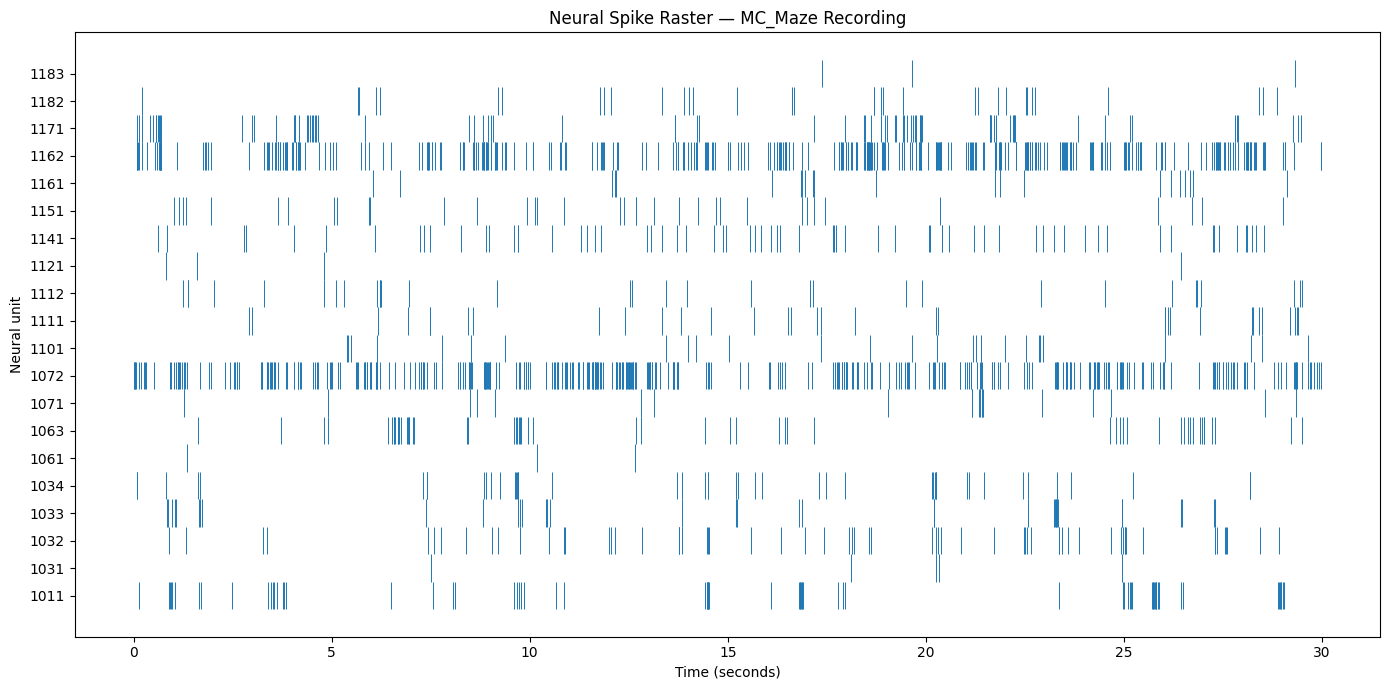

In [ ]:
# STEP 11 — Neural spike raster plot

import matplotlib.pyplot as plt
import numpy as np

unit_ids = nwb.units.id[:]

# Plot the first 20 recorded units
n_units_to_plot = min(20, len(unit_ids))

plt.figure(figsize=(14, 7))

for row, unit_id in enumerate(unit_ids[:n_units_to_plot]):
    spikes = nwb.units["spike_times"][row]

    # Show only the first 30 seconds
    spikes = spikes[(spikes >= 0) & (spikes <= 30)]

    plt.vlines(
        spikes,
        row + 0.5,
        row + 1.5,
        linewidth=0.7
    )

plt.xlabel("Time (seconds)")
plt.ylabel("Neural unit")
plt.title("Neural Spike Raster — MC_Maze Recording")
plt.yticks(
    np.arange(1, n_units_to_plot + 1),
    unit_ids[:n_units_to_plot]
)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 12 — Build population activity matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

print("🧠 BUILDING NEURAL POPULATION MATRIX")
print("=" * 60)

# Parameters
n_units = min(50, len(unit_ids))
bin_size = 0.1       # 100 ms bins
start_time = 0
end_time = 30

# Time bins
bins = np.arange(start_time, end_time + bin_size, bin_size)

# Activity matrix: time bins × neurons
activity = np.zeros((len(bins) - 1, n_units))

for neuron_idx in range(n_units):

    spikes = nwb.units["spike_times"][neuron_idx]

    # Keep spikes inside our analysis window
    spikes = spikes[
        (spikes >= start_time) &
        (spikes < end_time)
    ]

    # Convert spike times into firing counts
    counts, _ = np.histogram(spikes, bins=bins)

    activity[:, neuron_idx] = counts

print("Number of neurons:", n_units)
print("Number of time bins:", activity.shape[0])
print("Matrix shape:", activity.shape)
print("Total detected spikes:", int(activity.sum()))

# PCA
pca = PCA(n_components=3)
neural_latents = pca.fit_transform(activity)

print("\nPCA explained variance:")
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance:.3f}")

print(
    "\nVariance explained by first 3 PCs:",
    round(pca.explained_variance_ratio_.sum(), 3)
)

🧠 BUILDING NEURAL POPULATION MATRIX
Number of neurons: 50
Number of time bins: 300
Matrix shape: (300, 50)
Total detected spikes: 4132

PCA explained variance:
PC1: 0.196
PC2: 0.098
PC3: 0.083

Variance explained by first 3 PCs: 0.377


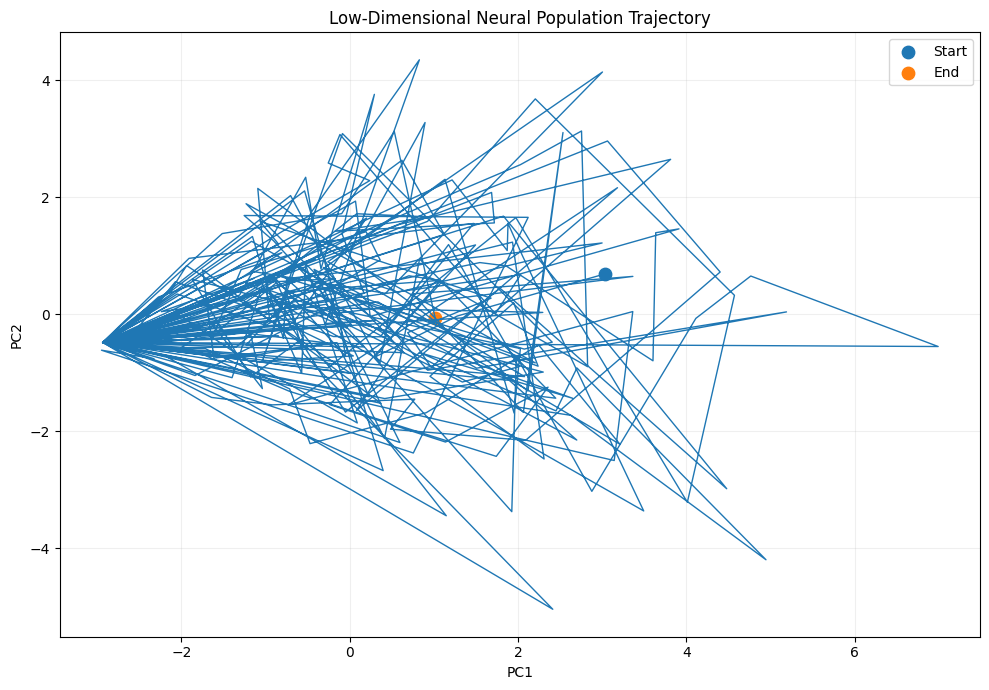

In [ ]:
# STEP 13 — Neural manifold visualization

plt.figure(figsize=(10, 7))

trajectory = neural_latents[:, :2]

plt.plot(
    trajectory[:, 0],
    trajectory[:, 1],
    linewidth=1
)

# Mark beginning and end
plt.scatter(
    trajectory[0, 0],
    trajectory[0, 1],
    s=80,
    label="Start"
)

plt.scatter(
    trajectory[-1, 0],
    trajectory[-1, 1],
    s=80,
    label="End"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Low-Dimensional Neural Population Trajectory")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 14 — Inspect available behavioral data

print("🔎 INSPECTING NWB DATA STRUCTURE")
print("=" * 60)

print("\nAcquisition:")
print(list(nwb.acquisition.keys()))

print("\nProcessing:")
print(list(nwb.processing.keys()))

print("\nTime intervals:")
print(list(nwb.intervals.keys()))

print("\nTrials:")
if nwb.trials is not None:
    print("Number of trials:", len(nwb.trials))
    print("Trial columns:")
    print(list(nwb.trials.colnames))
else:
    print("No trials table found.")

🔎 INSPECTING NWB DATA STRUCTURE

Acquisition:
[]

Processing:
[]

Time intervals:
['trials']

Trials:
Number of trials: 574
Trial columns:
['start_time', 'stop_time', 'move_onset_time', 'split']


In [ ]:
# STEP 14B — Inspect trial timing and split information

trials = nwb.trials

start = trials["start_time"][:]
stop = trials["stop_time"][:]
move_onset = trials["move_onset_time"][:]
split = trials["split"][:]

# Convert to numpy arrays
start = np.asarray(start)
stop = np.asarray(stop)
move_onset = np.asarray(move_onset)
split = np.asarray(split)

# Movement latency from trial start
move_latency = move_onset - start

print("🧠 TRIAL TIMING INSPECTION")
print("=" * 60)

print("Number of trials:", len(start))

print("\nTrial duration:")
print("  Mean:", round(np.mean(stop - start), 3), "seconds")
print("  Median:", round(np.median(stop - start), 3), "seconds")

print("\nMovement onset latency:")
print("  Mean:", round(np.mean(move_latency), 3), "seconds")
print("  Median:", round(np.median(move_latency), 3), "seconds")
print("  Min:", round(np.min(move_latency), 3), "seconds")
print("  Max:", round(np.max(move_latency), 3), "seconds")

print("\nSplit values:")
print(np.unique(split, return_counts=True))

print("\nFirst 10 trials:")
for i in range(min(10, len(start))):
    print(
        f"Trial {i}: "
        f"start={start[i]:.3f}, "
        f"move_onset={move_onset[i]:.3f}, "
        f"stop={stop[i]:.3f}, "
        f"latency={move_latency[i]:.3f}, "
        f"split={split[i]}"
    )

🧠 TRIAL TIMING INSPECTION
Number of trials: 574

Trial duration:
  Mean: 0.7 seconds
  Median: 0.7 seconds

Movement onset latency:
  Mean: 0.25 seconds
  Median: 0.25 seconds
  Min: 0.25 seconds
  Max: 0.25 seconds

Split values:
(array(['test'], dtype=object), array([574]))

First 10 trials:
Trial 0: start=0.000, move_onset=0.250, stop=0.700, latency=0.250, split=test
Trial 1: start=0.800, move_onset=1.050, stop=1.500, latency=0.250, split=test
Trial 2: start=1.600, move_onset=1.850, stop=2.300, latency=0.250, split=test
Trial 3: start=2.400, move_onset=2.650, stop=3.100, latency=0.250, split=test
Trial 4: start=3.200, move_onset=3.450, stop=3.900, latency=0.250, split=test
Trial 5: start=4.000, move_onset=4.250, stop=4.700, latency=0.250, split=test
Trial 6: start=4.800, move_onset=5.050, stop=5.500, latency=0.250, split=test
Trial 7: start=5.600, move_onset=5.850, stop=6.300, latency=0.250, split=test
Trial 8: start=6.400, move_onset=6.650, stop=7.100, latency=0.250, split=test
Tri

In [ ]:
# STEP 15 — Inspect neural unit metadata

print("🧠 NEURAL UNIT METADATA")
print("=" * 60)

print("Number of units:", len(nwb.units.id[:]))

print("\nAvailable unit columns:")
print(nwb.units.colnames)

print("\nFirst 5 units:")
for column in nwb.units.colnames:
    try:
        values = nwb.units[column][:]
        print(f"\n{column}:")
        print(values[:5])
    except Exception as e:
        print(f"\n{column}: <unable to display>")

🧠 NEURAL UNIT METADATA
Number of units: 137

Available unit columns:
('heldout', 'spike_times', 'obs_intervals', 'electrodes')

First 5 units:

heldout:
[False False False False False]

spike_times:
[array([1.31367000e-01, 8.92367000e-01, 9.27433000e-01, ...,
       4.55292100e+02, 4.56074900e+02, 4.58573433e+02]), array([  7.510567,  18.110233,  20.266033,  20.343133,  24.950067,
        30.401733,  30.769067,  32.040533,  33.923033,  33.993733,
        40.0777  ,  40.8008  ,  40.822033,  41.149467,  41.336667,
        42.419567,  42.5731  ,  45.6012  ,  45.825767,  47.480867,
        56.937133,  57.2942  ,  58.676   ,  62.660967,  64.3169  ,
        77.8026  ,  79.527433,  93.9015  ,  93.970833,  94.572733,
        94.6006  , 104.1105  , 107.3895  , 112.214567, 120.8585  ,
       127.2945  , 127.374167, 127.457533, 127.511767, 128.416633,
       132.276767, 136.258833, 136.363267, 139.672933, 139.853033,
       140.837   , 141.173833, 141.444433, 146.417567, 146.542033,
       146.61

In [ ]:
# ============================================================
# STEP 15: ALIGN NEURAL ACTIVITY TO MOVEMENT ONSET
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

print("🧠 ALIGNING NEURAL ACTIVITY TO MOVEMENT")
print("=" * 60)

# Analysis window around movement onset
pre_time = 0.20       # 200 ms before movement
post_time = 0.45      # 450 ms after movement
bin_size = 0.01       # 10 ms bins

# Time bins
time_bins = np.arange(-pre_time, post_time + bin_size, bin_size)
time_centers = time_bins[:-1] + bin_size / 2

n_trials = len(nwb.trials["start_time"])
n_units = len(nwb.units["spike_times"])
n_bins = len(time_centers)

print(f"Trials: {n_trials}")
print(f"Neural units: {n_units}")
print(f"Time window: {pre_time}s before → {post_time}s after movement")
print(f"Bin size: {bin_size}s")
print(f"Number of time bins: {n_bins}")

# Store firing rates:
# dimensions = trials × neurons × time bins
aligned_firing_rates = np.zeros((n_trials, n_units, n_bins))

# Get trial movement onset times
move_onsets = np.array(nwb.trials["move_onset_time"])

# Calculate spike counts for every trial and neuron
for trial_idx in range(n_trials):

    movement_time = move_onsets[trial_idx]

    # Absolute time window for this trial
    window_start = movement_time - pre_time
    window_end = movement_time + post_time

    for unit_idx in range(n_units):

        spikes = np.asarray(nwb.units["spike_times"][unit_idx])

        # Select spikes inside this trial's movement-centered window
        mask = (spikes >= window_start) & (spikes < window_end)
        relative_spikes = spikes[mask] - movement_time

        # Bin spikes
        counts, _ = np.histogram(relative_spikes, bins=time_bins)

        # Convert spike counts → firing rate (Hz)
        aligned_firing_rates[trial_idx, unit_idx, :] = counts / bin_size

print("\n✅ Alignment complete!")
print("Firing-rate matrix shape:", aligned_firing_rates.shape)
print(f"Expected: ({n_trials}, {n_units}, {n_bins})")

🧠 ALIGNING NEURAL ACTIVITY TO MOVEMENT
Trials: 574
Neural units: 137
Time window: 0.2s before → 0.45s after movement
Bin size: 0.01s
Number of time bins: 65

✅ Alignment complete!
Firing-rate matrix shape: (574, 137, 65)
Expected: (574, 137, 65)


🧠 POPULATION FIRING DYNAMICS
Trials averaged: 574
Neurons averaged: 137
Time bins: 65

Mean firing rate before movement: 4.6 Hz
Mean firing rate after movement: 4.1 Hz


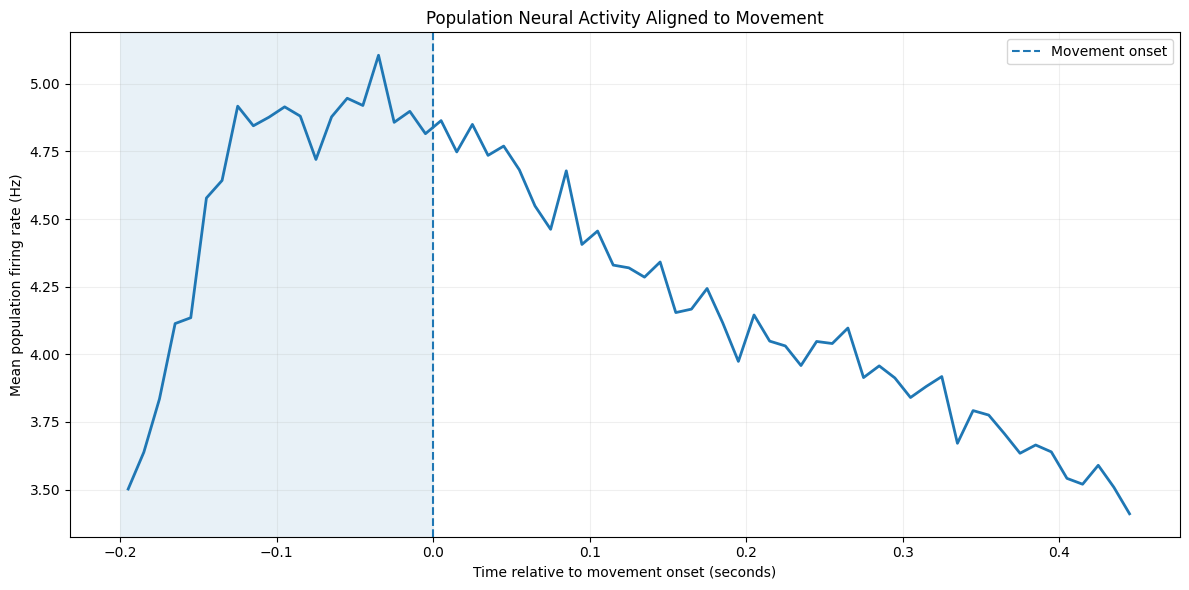

In [ ]:
# ============================================================
# STEP 16 — POPULATION FIRING DYNAMICS AROUND MOVEMENT
# ============================================================

# Average firing rate across trials
mean_population_activity = aligned_firing_rates.mean(axis=0)

# Average across neurons
population_mean = mean_population_activity.mean(axis=0)

print("🧠 POPULATION FIRING DYNAMICS")
print("=" * 60)

print("Trials averaged:", aligned_firing_rates.shape[0])
print("Neurons averaged:", aligned_firing_rates.shape[1])
print("Time bins:", aligned_firing_rates.shape[2])

print("\nMean firing rate before movement:",
      round(population_mean[time_centers < 0].mean(), 2), "Hz")

print("Mean firing rate after movement:",
      round(population_mean[time_centers >= 0].mean(), 2), "Hz")

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    time_centers,
    population_mean,
    linewidth=2
)

# Movement onset
plt.axvline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Movement onset"
)

plt.axvspan(
    -0.2,
    0,
    alpha=0.1
)

plt.xlabel("Time relative to movement onset (seconds)")
plt.ylabel("Mean population firing rate (Hz)")
plt.title("Population Neural Activity Aligned to Movement")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# STEP 17 — Neuron-level movement response

pre_mask = (time_centers >= -0.20) & (time_centers < 0)
post_mask = (time_centers >= 0) & (time_centers < 0.45)

pre_rates = aligned_firing_rates[:, :, pre_mask].mean(axis=2)
post_rates = aligned_firing_rates[:, :, post_mask].mean(axis=2)

mean_pre = pre_rates.mean(axis=0)
mean_post = post_rates.mean(axis=0)

firing_change = mean_post - mean_pre

print("🧠 NEURON-LEVEL MOVEMENT RESPONSE")
print("=" * 60)

print("Number of neurons:", n_units)

print("Mean pre-movement firing:",
      round(mean_pre.mean(), 3), "Hz")

print("Mean post-movement firing:",
      round(mean_post.mean(), 3), "Hz")

print("\nNeurons increasing:",
      np.sum(firing_change > 0))

print("Neurons decreasing:",
      np.sum(firing_change < 0))

print("\nStrongest increases:")
for idx in np.argsort(firing_change)[-10:][::-1]:
    print(
        f"Neuron {idx}: "
        f"{mean_pre[idx]:.2f} → {mean_post[idx]:.2f} Hz "
        f"({firing_change[idx]:+.2f} Hz)"
    )

print("\nStrongest decreases:")
for idx in np.argsort(firing_change)[:10]:
    print(
        f"Neuron {idx}: "
        f"{mean_pre[idx]:.2f} → {mean_post[idx]:.2f} Hz "
        f"({firing_change[idx]:+.2f} Hz)"
    )

🧠 NEURON-LEVEL MOVEMENT RESPONSE
Number of neurons: 137
Mean pre-movement firing: 4.601 Hz
Mean post-movement firing: 4.097 Hz

Neurons increasing: 60
Neurons decreasing: 77

Strongest increases:
Neuron 53: 2.45 → 9.24 Hz (+6.79 Hz)
Neuron 54: 4.35 → 8.88 Hz (+4.53 Hz)
Neuron 57: 5.42 → 9.70 Hz (+4.28 Hz)
Neuron 37: 2.78 → 6.97 Hz (+4.19 Hz)
Neuron 23: 16.05 → 19.50 Hz (+3.45 Hz)
Neuron 84: 9.21 → 11.90 Hz (+2.69 Hz)
Neuron 134: 15.44 → 18.10 Hz (+2.65 Hz)
Neuron 47: 1.54 → 4.01 Hz (+2.47 Hz)
Neuron 109: 19.90 → 22.35 Hz (+2.45 Hz)
Neuron 65: 1.70 → 4.06 Hz (+2.36 Hz)

Strongest decreases:
Neuron 89: 16.24 → 7.07 Hz (-9.17 Hz)
Neuron 8: 19.62 → 12.42 Hz (-7.19 Hz)
Neuron 104: 14.76 → 7.83 Hz (-6.93 Hz)
Neuron 49: 7.20 → 0.33 Hz (-6.87 Hz)
Neuron 132: 15.27 → 9.42 Hz (-5.85 Hz)
Neuron 0: 6.59 → 0.82 Hz (-5.77 Hz)
Neuron 77: 12.51 → 6.93 Hz (-5.57 Hz)
Neuron 127: 8.23 → 3.26 Hz (-4.98 Hz)
Neuron 117: 7.79 → 2.95 Hz (-4.84 Hz)
Neuron 116: 5.93 → 1.39 Hz (-4.54 Hz)


In [ ]:
# ============================================================
# STEP 18 — STATISTICAL TEST OF MOVEMENT-RELATED ACTIVITY
# ============================================================

from scipy.stats import wilcoxon

p_values = np.ones(n_units)
effect_sizes = np.zeros(n_units)

for neuron in range(n_units):

    # Trial-level firing rates
    before = pre_rates[:, neuron]
    after = post_rates[:, neuron]

    # Paired non-parametric test
    try:
        statistic, p = wilcoxon(before, after)
        p_values[neuron] = p
    except ValueError:
        p_values[neuron] = 1.0

    # Mean change
    effect_sizes[neuron] = after.mean() - before.mean()

# Multiple-comparison correction: Benjamini-Hochberg FDR
from statsmodels.stats.multitest import multipletests

significant, corrected_p, _, _ = multipletests(
    p_values,
    alpha=0.05,
    method="fdr_bh"
)

print("🧠 STATISTICAL MOVEMENT RESPONSE")
print("=" * 60)

print("Total neurons:", n_units)
print("Significant neurons (FDR < 0.05):", significant.sum())

print(
    "Significant increases:",
    np.sum(significant & (effect_sizes > 0))
)

print(
    "Significant decreases:",
    np.sum(significant & (effect_sizes < 0))
)

print("\nTop statistically strongest neurons:")

top_neurons = np.argsort(corrected_p)[:10]

for neuron in top_neurons:
    print(
        f"Neuron {neuron}: "
        f"Δ={effect_sizes[neuron]:+.2f} Hz, "
        f"raw p={p_values[neuron]:.4g}, "
        f"FDR p={corrected_p[neuron]:.4g}"
    )

🧠 STATISTICAL MOVEMENT RESPONSE
Total neurons: 137
Significant neurons (FDR < 0.05): 104
Significant increases: 44
Significant decreases: 60

Top statistically strongest neurons:
Neuron 53: Δ=+6.79 Hz, raw p=2.313e-62, FDR p=3.168e-60
Neuron 49: Δ=-6.87 Hz, raw p=9.619e-55, FDR p=6.589e-53
Neuron 89: Δ=-9.17 Hz, raw p=7.863e-54, FDR p=3.591e-52
Neuron 116: Δ=-4.54 Hz, raw p=7.98e-50, FDR p=2.733e-48
Neuron 104: Δ=-6.93 Hz, raw p=1.217e-43, FDR p=3.336e-42
Neuron 77: Δ=-5.57 Hz, raw p=5.705e-41, FDR p=1.303e-39
Neuron 0: Δ=-5.77 Hz, raw p=8.364e-41, FDR p=1.637e-39
Neuron 50: Δ=-3.87 Hz, raw p=1.645e-40, FDR p=2.817e-39
Neuron 54: Δ=+4.53 Hz, raw p=6.25e-39, FDR p=9.514e-38
Neuron 37: Δ=+4.19 Hz, raw p=6.642e-38, FDR p=9.099e-37


🧠 BUILDING TRIAL-LEVEL NEURAL MANIFOLD
Trial × neuron matrix: (574, 137)

PCA explained variance:
PC1: 0.0470
PC2: 0.0460
PC3: 0.0317

First 3 PCs combined: 0.1247


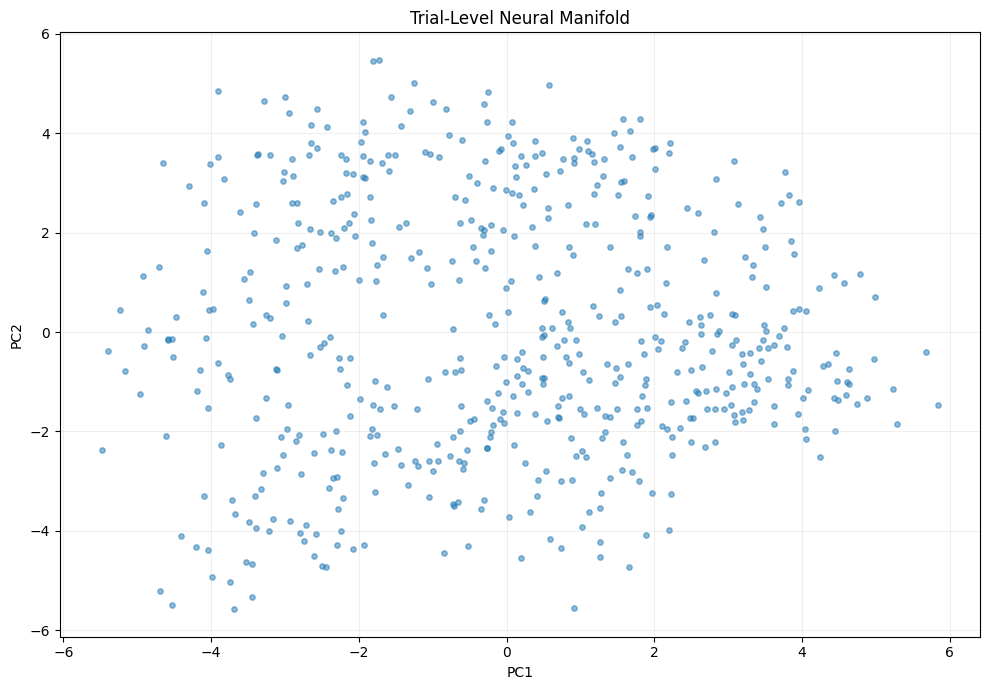

In [ ]:
# ============================================================
# STEP 19 — TRIAL-LEVEL NEURAL MANIFOLD
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("🧠 BUILDING TRIAL-LEVEL NEURAL MANIFOLD")
print("=" * 60)

# Use the 100 ms immediately after movement onset
analysis_mask = (
    (time_centers >= 0) &
    (time_centers < 0.20)
)

# Average firing rate during this window
trial_features = aligned_firing_rates[:, :, analysis_mask].mean(axis=2)

print("Trial × neuron matrix:", trial_features.shape)

# Standardize neurons
scaler = StandardScaler()
X_scaled = scaler.fit_transform(trial_features)

# PCA
pca_trials = PCA(n_components=3)
trial_latents = pca_trials.fit_transform(X_scaled)

print("\nPCA explained variance:")
for i, variance in enumerate(pca_trials.explained_variance_ratio_):
    print(f"PC{i+1}: {variance:.4f}")

print(
    "\nFirst 3 PCs combined:",
    round(pca_trials.explained_variance_ratio_.sum(), 4)
)

# Plot trial manifold
plt.figure(figsize=(10, 7))

plt.scatter(
    trial_latents[:, 0],
    trial_latents[:, 1],
    s=15,
    alpha=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Trial-Level Neural Manifold")
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

🧠 MEASURING TEMPORAL REPRESENTATIONAL DRIFT
Early trials: 287
Late trials: 287

PCA variance captured by 10 dimensions: 0.2594
Early centroid: [-0.051 -0.067 -0.098  0.153  0.122  0.017 -0.005  0.019 -0.097  0.039]
Late centroid: [ 0.051  0.067  0.098 -0.153 -0.122 -0.017  0.005 -0.019  0.097 -0.039]

Early → Late centroid distance: 0.5168


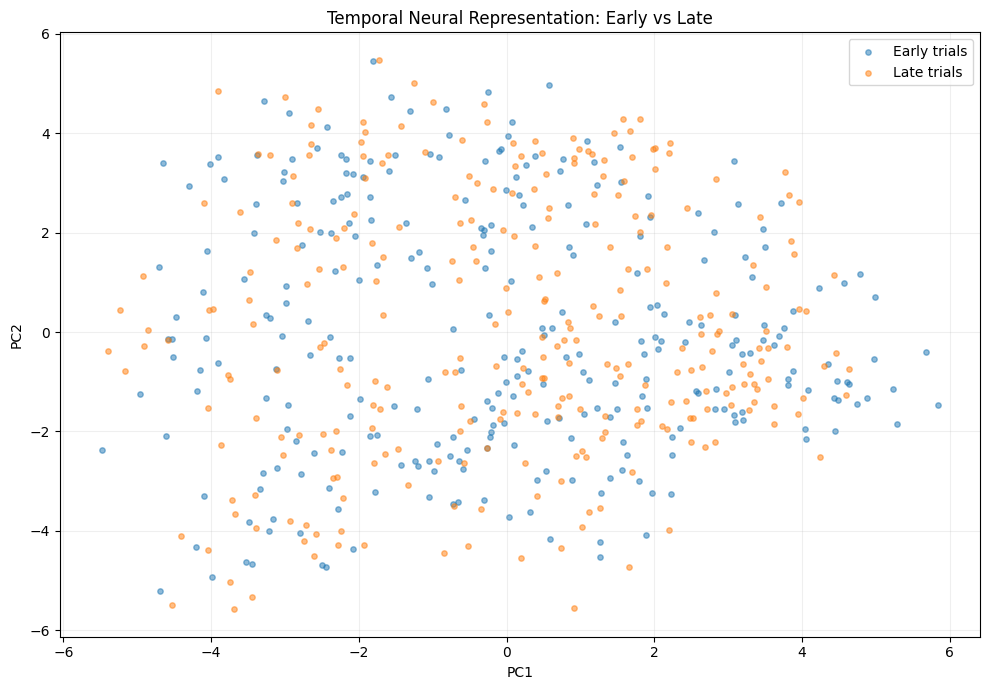

In [ ]:
# ============================================================
# STEP 20 — TEMPORAL REPRESENTATIONAL DRIFT
# ============================================================

from scipy.spatial.distance import cdist

print("🧠 MEASURING TEMPORAL REPRESENTATIONAL DRIFT")
print("=" * 60)

# Split trials into early and late periods
midpoint = len(trial_features) // 2

early_features = trial_features[:midpoint]
late_features = trial_features[midpoint:]

print("Early trials:", early_features.shape[0])
print("Late trials:", late_features.shape[0])

# Standardize using the complete dataset
scaler_drift = StandardScaler()

combined = np.vstack([early_features, late_features])
combined_scaled = scaler_drift.fit_transform(combined)

early_scaled = combined_scaled[:midpoint]
late_scaled = combined_scaled[midpoint:]

# PCA fitted across the complete recording
pca_drift = PCA(n_components=10)

combined_latents = pca_drift.fit_transform(combined_scaled)

early_latents = combined_latents[:midpoint]
late_latents = combined_latents[midpoint:]

# Compare population centroids
early_centroid = early_latents.mean(axis=0)
late_centroid = late_latents.mean(axis=0)

centroid_distance = np.linalg.norm(
    early_centroid - late_centroid
)

print("\nPCA variance captured by 10 dimensions:",
      round(pca_drift.explained_variance_ratio_.sum(), 4))

print("Early centroid:", np.round(early_centroid, 3))
print("Late centroid:", np.round(late_centroid, 3))

print(
    "\nEarly → Late centroid distance:",
    round(centroid_distance, 4)
)

# Visualize early vs late trials
plt.figure(figsize=(10, 7))

plt.scatter(
    early_latents[:, 0],
    early_latents[:, 1],
    s=15,
    alpha=0.5,
    label="Early trials"
)

plt.scatter(
    late_latents[:, 0],
    late_latents[:, 1],
    s=15,
    alpha=0.5,
    label="Late trials"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Temporal Neural Representation: Early vs Late")
plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 21A — INSPECT TRIAL LABELS
# ============================================================

print("🧠 TRIAL LABEL INSPECTION")
print("=" * 60)

trial_columns = list(trials.colnames)

print("Available trial columns:")
print(trial_columns)

print("\nNumber of trials:", len(trials))

print("\nFirst 5 rows:")
for col in trial_columns:
    try:
        values = trials[col][:]
        print(f"\n{col}:")
        print(values[:5])
    except Exception as e:
        print(f"{col}: could not read ({e})")

🧠 TRIAL LABEL INSPECTION
Available trial columns:
['start_time', 'stop_time', 'move_onset_time', 'split']

Number of trials: 574

First 5 rows:

start_time:
[0.  0.8 1.6 2.4 3.2]

stop_time:
[0.7 1.5 2.3 3.1 3.9]

move_onset_time:
[0.25 1.05 1.85 2.65 3.45]

split:
['test' 'test' 'test' 'test' 'test']


In [ ]:
# ============================================================
# STEP 21 — LABEL-FREE NEURAL REPRESENTATIONAL STABILITY
# ============================================================

from scipy.stats import pearsonr
import numpy as np

print("🧠 NEURAL REPRESENTATIONAL STABILITY")
print("=" * 60)

# ------------------------------------------------------------
# 1. Mean population activity for each trial
# ------------------------------------------------------------

early_mean = early_features.mean(axis=0)
late_mean = late_features.mean(axis=0)

# Correlation between early and late population profiles
corr, p_value = pearsonr(early_mean, late_mean)

print("Early population mean shape:", early_mean.shape)
print("Late population mean shape:", late_mean.shape)

print("\nEarly ↔ Late population correlation:")
print(f"r = {corr:.4f}")
print(f"p = {p_value:.4e}")

# ------------------------------------------------------------
# 2. Representational similarity
# ------------------------------------------------------------

# Correlation matrix between trials
early_similarity = np.corrcoef(early_features)
late_similarity = np.corrcoef(late_features)

# Extract upper triangles
upper = np.triu_indices_from(early_similarity, k=1)

early_vec = early_similarity[upper]
late_vec = late_similarity[upper]

rsa_corr, rsa_p = pearsonr(early_vec, late_vec)

print("\nRepresentational similarity:")
print(f"RSA correlation = {rsa_corr:.4f}")
print(f"p = {rsa_p:.4e}")

# ------------------------------------------------------------
# 3. Population activity change
# ------------------------------------------------------------

population_difference = np.linalg.norm(
    late_mean - early_mean
)

population_baseline = np.linalg.norm(early_mean)

relative_change = population_difference / population_baseline

print("\nPopulation activity displacement:")
print(f"Absolute difference = {population_difference:.4f}")
print(f"Relative change = {relative_change:.4f}")

# ------------------------------------------------------------
# 4. Summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)

print(f"Population correlation: {corr:.4f}")
print(f"Representational similarity: {rsa_corr:.4f}")
print(f"Relative population change: {relative_change:.4f}")

🧠 NEURAL REPRESENTATIONAL STABILITY
Early population mean shape: (137,)
Late population mean shape: (137,)

Early ↔ Late population correlation:
r = 0.9963
p = 2.1472e-145

Representational similarity:
RSA correlation = -0.0257
p = 2.0105e-07

Population activity displacement:
Absolute difference = 5.9381
Relative change = 0.0689

SUMMARY
Population correlation: 0.9963
Representational similarity: -0.0257
Relative population change: 0.0689
